In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from collections import Counter
import re
from openpyxl import Workbook

In [41]:
pq = pd.read_parquet('metadata.parquet')

In [42]:
js = pd.read_json('mapping.json')

In [121]:
print(pq.head())

        id shard  split  fps  sampling_rate  \
0  0070925   001  valid   25          16000   
1  0063053   001  valid   25          16000   
2  0076991   001  valid   25          16000   
3  0123846   001  train   25          16000   
4  0063937   001  valid   25          16000   

                                          transcript  video_num_frames  \
0  thành ra ở giêng nó vẫn hỏi hay hơn vậy thì mì...                76   
1  một á là chúng ta sẽ sử dụng da mi trên để mà ...                76   
2  là những đôi mắt có những cái độ xập xệ những ...                76   
3                 họ phải là nó chuẩn ai cũng sợ hết                76   
4  thì mình phải chọn một người đàn ông thật là t...                76   

   audio_num_frames  
0             48000  
1             48000  
2             48000  
3             48000  
4             48000  


In [122]:
print(js.head())

        id  shard  split                channel  \
0  0070925      1  valid  nguyenquynhnaricantho   
1  0063053      1  valid  nguyenquynhnaricantho   
2  0076991      1  valid  nguyenquynhnaricantho   
3  0123846      1  train  baothanhnien.official   
4  0063937      1  valid  nguyenquynhnaricantho   

                            video  
0  730979009993428507400000-84-87  
1   724976718687981082100016-8-11  
2    721226360185007644300006-4-7  
3    730225575020044622600005-5-8  
4    722692287566659917000002-2-5  


In [45]:
# Chuyển đổi cột 'id' trong js sang dạng chuỗi với cùng định dạng như trong pq
js['id'] = js['id'].astype(str).str.zfill(7)

# Ghép hai DataFrame dựa vào cột 'id'
merged_df = pd.merge(pq, js, on='id', how='inner')

# Hiển thị kết quả
print(merged_df.head())

        id shard_x split_x  fps  sampling_rate  \
0  0070925     001   valid   25          16000   
1  0063053     001   valid   25          16000   
2  0076991     001   valid   25          16000   
3  0123846     001   train   25          16000   
4  0063937     001   valid   25          16000   

                                          transcript  video_num_frames  \
0  thành ra ở giêng nó vẫn hỏi hay hơn vậy thì mì...                76   
1  một á là chúng ta sẽ sử dụng da mi trên để mà ...                76   
2  là những đôi mắt có những cái độ xập xệ những ...                76   
3                 họ phải là nó chuẩn ai cũng sợ hết                76   
4  thì mình phải chọn một người đàn ông thật là t...                76   

   audio_num_frames  shard_y split_y                channel  \
0             48000        1   valid  nguyenquynhnaricantho   
1             48000        1   valid  nguyenquynhnaricantho   
2             48000        1   valid  nguyenquynhnaricantho   
3 

In [46]:
# Tính số lượng từ trong mỗi transcript
merged_df['word_count'] = merged_df['transcript'].apply(lambda x: len(x.split()))

In [123]:
print(merged_df.head())

        id shard_x split_x  fps  sampling_rate  \
0  0070925     001   valid   25          16000   
1  0063053     001   valid   25          16000   
2  0076991     001   valid   25          16000   
3  0123846     001   train   25          16000   
4  0063937     001   valid   25          16000   

                                          transcript  video_num_frames  \
0  thành ra ở giêng nó vẫn hỏi hay hơn vậy thì mì...                76   
1  một á là chúng ta sẽ sử dụng da mi trên để mà ...                76   
2  là những đôi mắt có những cái độ xập xệ những ...                76   
3                 họ phải là nó chuẩn ai cũng sợ hết                76   
4  thì mình phải chọn một người đàn ông thật là t...                76   

   audio_num_frames  shard_y split_y                channel  \
0             48000        1   valid  nguyenquynhnaricantho   
1             48000        1   valid  nguyenquynhnaricantho   
2             48000        1   valid  nguyenquynhnaricantho   
3 

C:\Users\khanh\AppData\Local\Temp\ipykernel_7612\2508748719.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


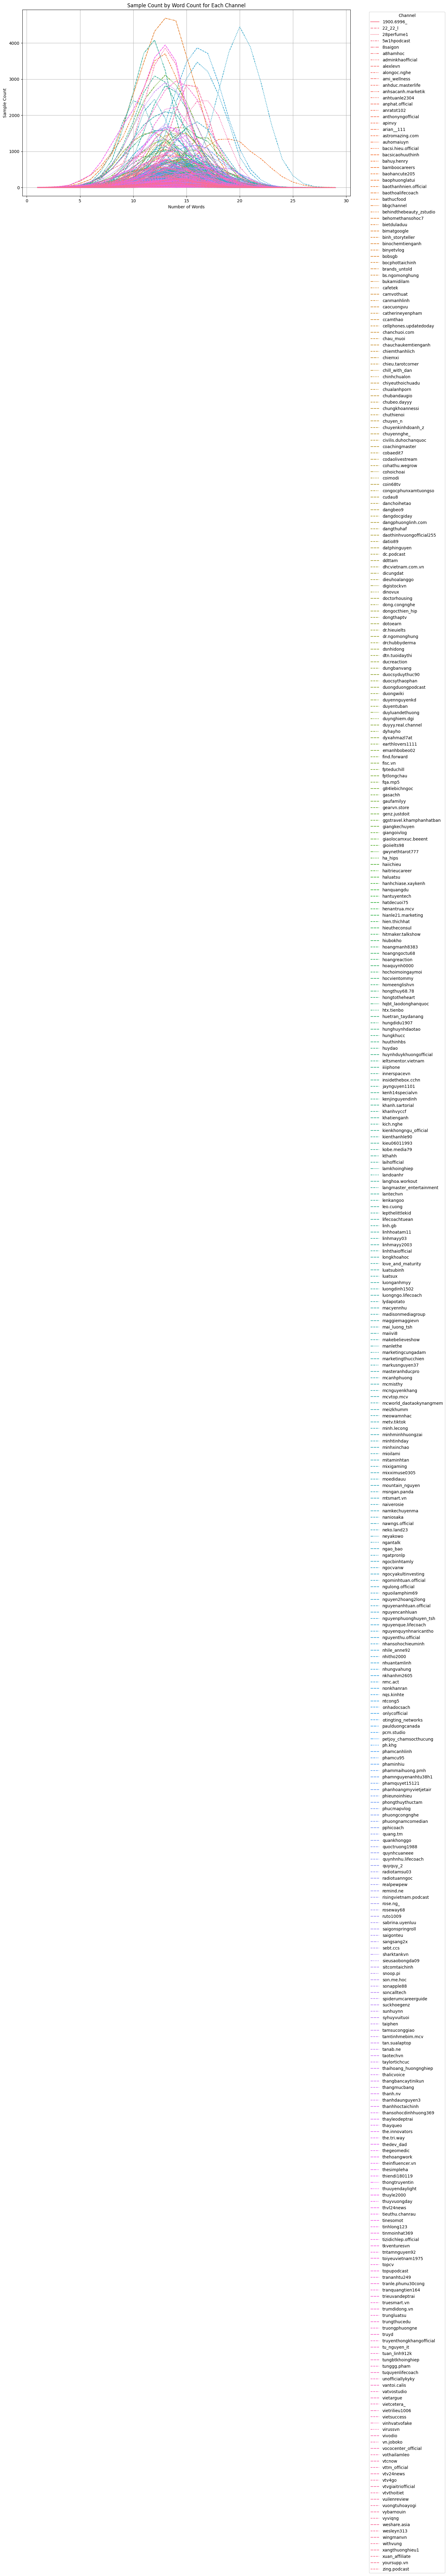

In [65]:
# Calculate the number of samples for each channel and word count
channel_word_count = merged_df.groupby(['channel', 'word_count']).size().reset_index(name='sample_count')

# Sort the DataFrame by 'sample_count' in descending order
channel_word_count = channel_word_count.sort_values(by='sample_count', ascending=False).reset_index(drop=True)

# Pivot the data to make it easier to plot
pivot_df = channel_word_count.pivot_table(index='word_count', columns='channel', values='sample_count', fill_value=0)

# Plot the data
plt.figure(figsize=(14, 8))
sns.lineplot(data=pivot_df)
plt.xlabel('Number of Words')
plt.ylabel('Sample Count')
plt.title('Sample Count by Word Count for Each Channel')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Save the plot to a file
plt.savefig('sentence_length/samples_by_word_count.png', bbox_inches='tight')

# Display the plot
plt.show()

In [64]:
# Tính tỷ lệ mẫu cần lấy (10%)
sample_fraction = 0.1

# Tạo danh sách để lưu dữ liệu từ mỗi kênh
df_list = []

# Lấy dữ liệu của từng kênh
for channel in merged_df['channel'].unique():
    channel_data = merged_df[merged_df['channel'] == channel]
    # Lấy 10% dữ liệu từ kênh hiện tại
    sample_data = channel_data.sample(frac=sample_fraction, random_state=42)
    df_list.append(sample_data)

# Gộp tất cả dữ liệu từ các kênh vào một DataFrame
df100h = pd.concat(df_list, ignore_index=True)

# Hiển thị thông tin về df100h
print(df100h.info())
print(df100h.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125447 entries, 0 to 125446
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                125447 non-null  object
 1   shard_x           125447 non-null  object
 2   split_x           125447 non-null  object
 3   fps               125447 non-null  int8  
 4   sampling_rate     125447 non-null  int64 
 5   transcript        125447 non-null  object
 6   video_num_frames  125447 non-null  int64 
 7   audio_num_frames  125447 non-null  int64 
 8   shard_y           125447 non-null  int64 
 9   split_y           125447 non-null  object
 10  channel           125447 non-null  object
 11  video             125447 non-null  object
 12  word_count        125447 non-null  int64 
dtypes: int64(5), int8(1), object(7)
memory usage: 11.6+ MB
None
        id shard_x split_x  fps  sampling_rate  \
0  0064655     015   valid   25          16000   
1  0065896     018 

C:\Users\khanh\AppData\Local\Temp\ipykernel_7612\1095726517.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


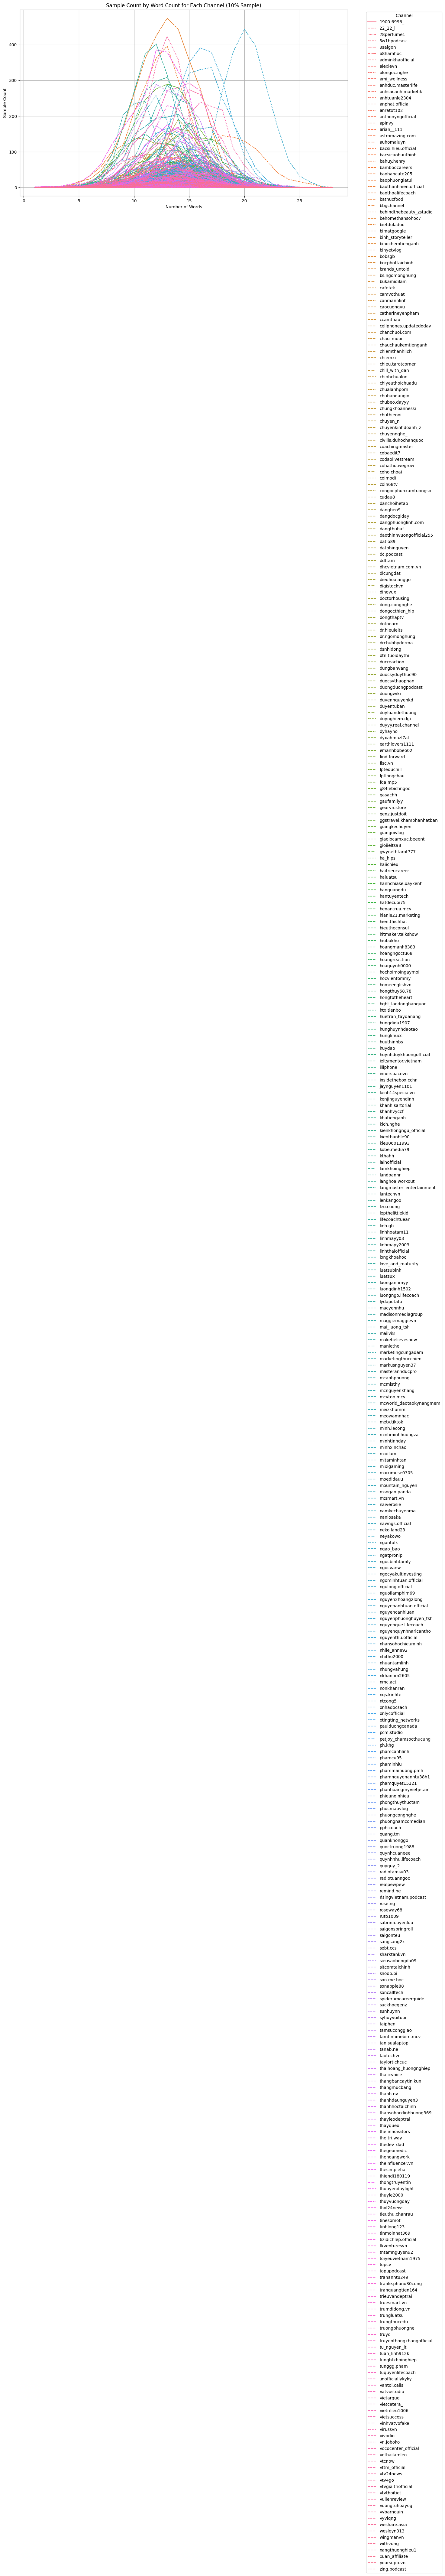

In [66]:
# Tính số lượng mẫu cho từng kênh và số lượng từ
channel_word_count = df100h.groupby(['channel', 'word_count']).size().reset_index(name='sample_count')

# Tạo dữ liệu phù hợp để vẽ đồ thị
pivot_df = channel_word_count.pivot_table(index='word_count', columns='channel', values='sample_count', fill_value=0)

# Vẽ đồ thị
plt.figure(figsize=(14, 8))
sns.lineplot(data=pivot_df)
plt.xlabel('Number of Words')
plt.ylabel('Sample Count')
plt.title('Sample Count by Word Count for Each Channel (10% Sample)')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Lưu hình ảnh vào file
plt.savefig('sentence_length/100h_samples_by_word_count.png', bbox_inches='tight')

# Hiển thị hình ảnh
plt.show()

C:\Users\khanh\AppData\Local\Temp\ipykernel_7612\3178594374.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = channel_word_count.pivot_table(index='word_count', columns='channel', values='sample_count', fill_value=0)
C:\Users\khanh\AppData\Local\Temp\ipykernel_7612\3178594374.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


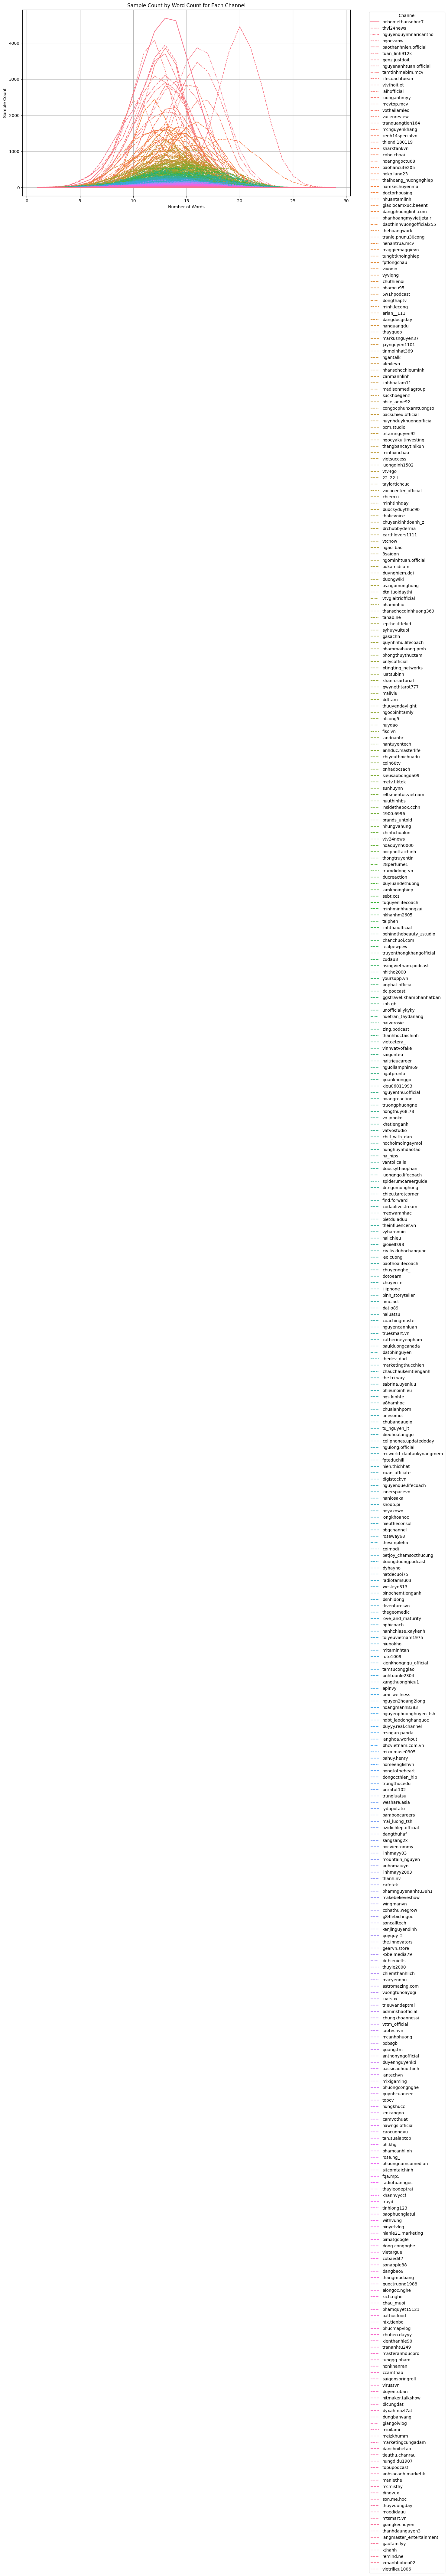

In [61]:
# Calculate the number of samples for each channel and word count
channel_word_count = merged_df.groupby(['channel', 'word_count']).size().reset_index(name='sample_count')

# Calculate the total sample count for each channel
total_sample_counts = channel_word_count.groupby('channel')['sample_count'].sum().reset_index()
total_sample_counts = total_sample_counts.sort_values(by='sample_count', ascending=False).reset_index(drop=True)

# Create a mapping of channels to their sorted order
channel_order = total_sample_counts['channel'].tolist()

# Reorder the DataFrame based on the sorted channel order
channel_word_count['channel'] = pd.Categorical(channel_word_count['channel'], categories=channel_order, ordered=True)
channel_word_count = channel_word_count.sort_values(by=['channel', 'word_count']).reset_index(drop=True)

# Pivot the data to make it easier to plot
pivot_df = channel_word_count.pivot_table(index='word_count', columns='channel', values='sample_count', fill_value=0)

# Plot the data
plt.figure(figsize=(14, 8))
sns.lineplot(data=pivot_df)
plt.xlabel('Number of Words')
plt.ylabel('Sample Count')
plt.title('Sample Count by Word Count for Each Channel')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Save the plot to a file
plt.savefig('sentence_length/samples_by_word_count.png', bbox_inches='tight')

# Display the plot
plt.show()

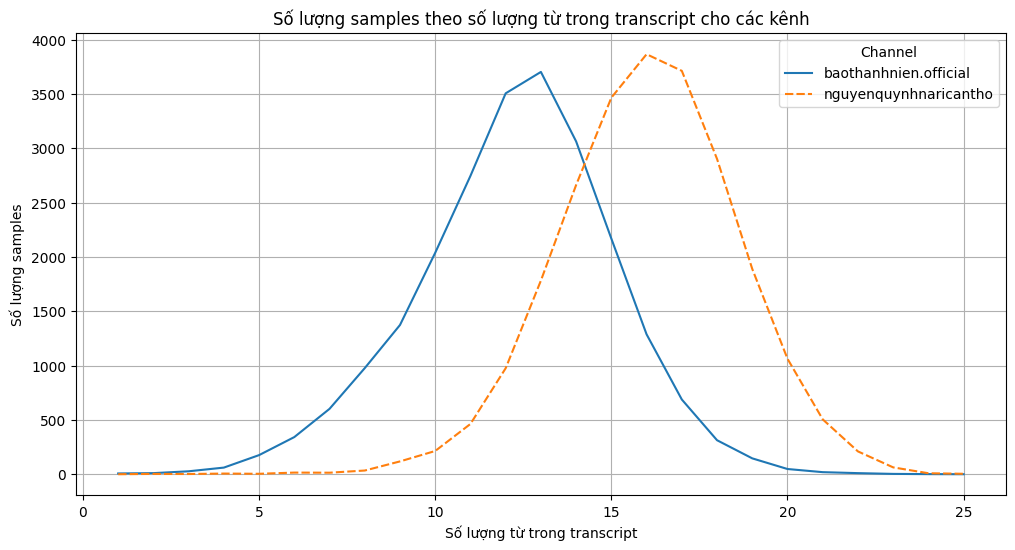

In [51]:
# Lọc dữ liệu theo channel
filtered_df = merged_df[merged_df['channel'].isin(['nguyenquynhnaricantho', 'baothanhnien.official'])]

# Tính số lượng mẫu cho từng channel
channel_sample_counts = filtered_df.groupby(['channel', 'word_count']).size().reset_index(name='sample_count')

# Pivot dữ liệu để dễ dàng vẽ đồ thị
pivot_df = channel_sample_counts.pivot(index='word_count', columns='channel', values='sample_count').fillna(0)

# Vẽ đồ thị
plt.figure(figsize=(12, 6))
sns.lineplot(data=pivot_df)
plt.xlabel('Số lượng từ trong transcript')
plt.ylabel('Số lượng samples')
plt.title('Số lượng samples theo số lượng từ trong transcript cho các kênh')
plt.legend(title='Channel')
plt.grid(True)
plt.show()

In [59]:
# Group by 'channel' and count the number of samples
channel_counts = merged_df.groupby('channel').size().reset_index(name='sample_count')

# Sort the DataFrame by 'sample_count' in descending order
channel_counts = channel_counts.sort_values(by='sample_count', ascending=False).reset_index(drop=True)

# Display the sorted DataFrame
print(channel_counts)

                   channel  sample_count
0         behomethansohoc7         32370
1               thvl24news         24243
2    nguyenquynhnaricantho         23990
3                 ngocvanw         23617
4    baothanhnien.official         23322
..                     ...           ...
401             gaufamilyy            40
402                 kthahh            40
403              remind.ne            28
404           emanhbobeo02            12
405         vietrilieu1006            10

[406 rows x 2 columns]


In [103]:
# Ensure the directory exists
os.makedirs('sentence_length', exist_ok=True)

# Get all unique channels
channels = merged_df['channel'].unique()

# Loop through each channel and create a plot
for channel in channels:
    # Filter the data for the current channel
    channel_data = merged_df[merged_df['channel'] == channel]

    # Calculate the number of samples for each word count
    channel_word_count = channel_data.groupby('word_count').size().reset_index(name='sample_count')

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(channel_word_count['word_count'], channel_word_count['sample_count'])
    plt.xlabel('Number of Words')
    plt.ylabel('Sample Count')
    plt.title(f'Sample Count by Word Count for Channel: {channel}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Save the plot with the channel name as the filename
    plt.savefig(f'sentence_length/{channel}.png')

    # Close the plot to free memory
    plt.close()

print("All plots have been saved.")

All plots have been saved.


In [107]:
# Get the first unique channel
first_channel = merged_df['channel'].unique()[0]

# Filter the data for the first channel
channel_data = merged_df[merged_df['channel'] == first_channel]

# Combine all transcripts into one text
all_transcripts = ' '.join(channel_data['transcript'])

# Split the text into words and count unique words
words = re.findall(r'\b\w+\b', all_transcripts.lower())
word_counts = Counter(words)

# Print the number of unique words
print(f'Number of unique words for channel {first_channel}: {len(word_counts)}')

Number of unique words for channel nguyenquynhnaricantho: 3704


In [109]:
# Get the first unique channel
first_channel = merged_df['channel'].unique()[0]

# Filter the data for the first channel
channel_data = merged_df[merged_df['channel'] == first_channel]

# Combine all transcripts into one text
all_transcripts = ' '.join(channel_data['transcript'])

# Split the text into words and count unique words
words = re.findall(r'\b\w+\b', all_transcripts.lower())
word_counts = Counter(words)

# Sort the word counts by count in descending order
sorted_word_counts = dict(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the number of unique words
print(f'Number of unique words for channel {first_channel}: {len(word_counts)}')

# Print the unique words and their counts
print("Unique words and their counts (sorted by count):")
for word, count in sorted_word_counts.items():
    print(f'{word}: {count}')


Number of unique words for channel nguyenquynhnaricantho: 3704
Unique words and their counts (sorted by count):
là: 17416
cái: 14314
người: 9123
mà: 7864
có: 7331
mình: 7212
thì: 6998
nó: 6961
á: 6428
một: 4793
đó: 4678
không: 4604
của: 4581
ta: 4464
như: 4101
những: 3402
này: 3367
cho: 3210
làm: 2921
sẽ: 2916
cũng: 2909
mọi: 2871
chị: 2821
và: 2806
đi: 2796
rồi: 2772
với: 2769
rất: 2384
phải: 2288
để: 2264
khi: 2262
tôi: 2208
em: 2157
được: 2028
nói: 1913
con: 1863
ra: 1805
nhưng: 1685
chúng: 1659
trong: 1639
anh: 1637
vậy: 1564
ở: 1511
ông: 1496
sự: 1468
tại: 1418
nhiều: 1391
bạn: 1370
họ: 1369
lại: 1363
về: 1361
vì: 1336
nào: 1331
hai: 1326
gì: 1242
giờ: 1197
chuyện: 1184
thể: 1170
thôi: 1162
thấy: 1152
biết: 1132
thật: 1128
chỉ: 1090
bên: 1088
các: 1055
đã: 1037
dụ: 1019
đẹp: 1007
kia: 1000
còn: 993
tiền: 989
ví: 956
bị: 944
nha: 933
hay: 921
hàng: 916
khách: 910
cảm: 910
bà: 900
tới: 897
quá: 875
mới: 869
lúc: 864
vào: 863
sau: 829
nên: 816
nhau: 804
việc: 801
bây: 763
lên: 760
ba

In [114]:
# Get the first unique channel
first_channel = merged_df['channel'].unique()[0]

# Filter the data for the first channel
channel_data = merged_df[merged_df['channel'] == first_channel]

# Combine all transcripts into one text
all_transcripts = ' '.join(channel_data['transcript'])

# Split the text into words and count unique words
words = re.findall(r'\b\w+\b', all_transcripts.lower())
word_counts = Counter(words)

# Sort the word counts by count in descending order
sorted_word_counts = dict(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))

# Convert to DataFrame for saving
word_count_df = pd.DataFrame(sorted_word_counts.items(), columns=['word', 'count'])

# Save to CSV
output_filename = f'vocab/{first_channel}_word_counts.csv'
word_count_df.to_csv(output_filename, index=False)

print(f'Number of unique words for channel {first_channel}: {len(word_counts)}')
print(f'Unique words and their counts have been saved to {output_filename}')


ValueError: No engine for filetype: 'excel'

In [119]:
# Ensure the output directory exists
os.makedirs('vocab', exist_ok=True)

# Get all unique channels
channels = merged_df['channel'].unique()

for channel in channels:
    # Filter the data for the current channel
    channel_data = merged_df[merged_df['channel'] == channel]

    # Combine all transcripts into one text
    all_transcripts = ' '.join(channel_data['transcript'])

    # Split the text into words and count unique words
    words = re.findall(r'\b\w+\b', all_transcripts.lower())
    word_counts = Counter(words)

    # Sort the word counts by count in descending order
    sorted_word_counts = dict(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))

    # Convert to DataFrame for saving
    word_count_df = pd.DataFrame(sorted_word_counts.items(), columns=['word', 'count'])

    # Determine the number of unique words
    num_unique_words = len(word_counts)

    # Save to Excel
    output_filename = f'vocab/{num_unique_words}_vocab_{channel}.xlsx'

    # Create a pandas Excel writer using openpyxl as the engine
    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        # Write the additional information in the first two rows
        sheet = writer.book.create_sheet('Sheet1')
        sheet['A1'] = f'Number of unique words for channel {channel}: {num_unique_words}'
        sheet['A2'] = 'Unique words and their counts (sorted by count):'
        
        # Write the DataFrame to the worksheet starting from the fourth row
        word_count_df.to_excel(writer, sheet_name='Sheet1', startrow=3, index=False)

    print(f'Number of unique words for channel {channel}: {num_unique_words}')
    print(f'Unique words and their counts have been saved to {output_filename}')

Number of unique words for channel nguyenquynhnaricantho: 3704
Unique words and their counts have been saved to vocab/3704_vocab_nguyenquynhnaricantho.xlsx
Number of unique words for channel baothanhnien.official: 3601
Unique words and their counts have been saved to vocab/3601_vocab_baothanhnien.official.xlsx
Number of unique words for channel behomethansohoc7: 3444
Unique words and their counts have been saved to vocab/3444_vocab_behomethansohoc7.xlsx
Number of unique words for channel ngocvanw: 3939
Unique words and their counts have been saved to vocab/3939_vocab_ngocvanw.xlsx
Number of unique words for channel thvl24news: 3248
Unique words and their counts have been saved to vocab/3248_vocab_thvl24news.xlsx
Number of unique words for channel laihofficial: 3356
Unique words and their counts have been saved to vocab/3356_vocab_laihofficial.xlsx
Number of unique words for channel dr.hieuielts: 1114
Unique words and their counts have been saved to vocab/1114_vocab_dr.hieuielts.xlsx
Nu

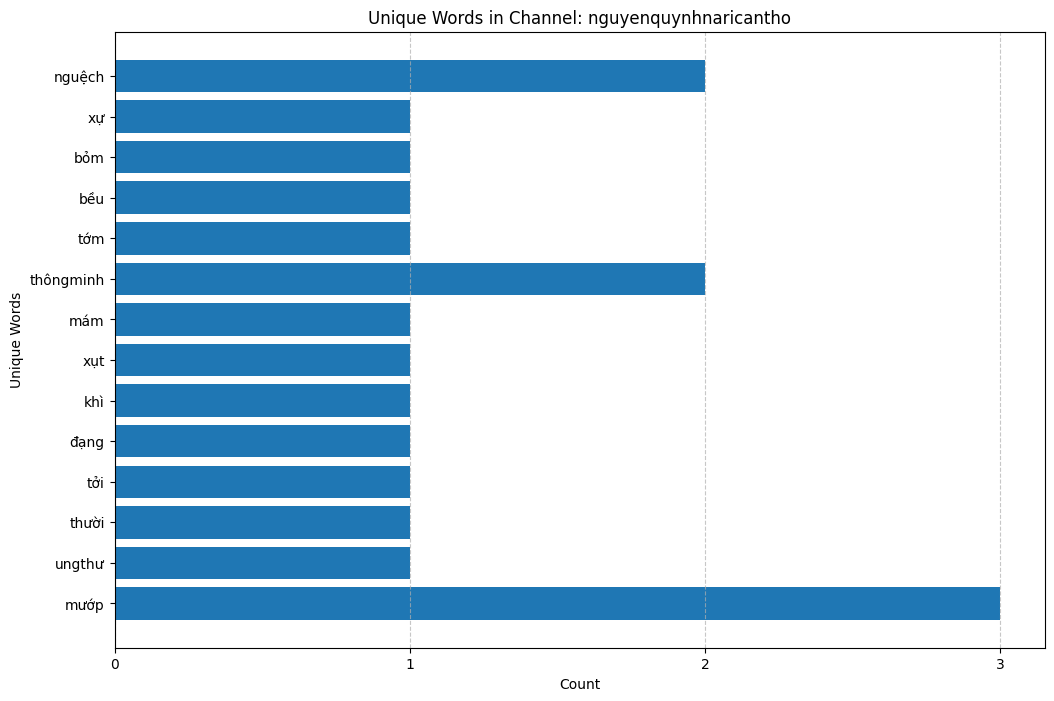

In [127]:
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

# Function to extract unique words from transcripts
def extract_words(data):
    all_transcripts = ' '.join(data['transcript'])
    words = re.findall(r'\b\w+\b', all_transcripts.lower())
    return set(words)

# Get the first unique channel
first_channel = merged_df['channel'].unique()[0]

# Filter the data for the first channel
channel_data = merged_df[merged_df['channel'] == first_channel]

# Extract unique words from the first channel
first_channel_words = extract_words(channel_data)

# Extract unique words from all other channels
other_channels_words = set()
for channel in merged_df['channel'].unique():
    if channel != first_channel:
        other_channel_data = merged_df[merged_df['channel'] == channel]
        other_channels_words.update(extract_words(other_channel_data))

# Find words unique to the first channel
unique_first_channel_words = first_channel_words - other_channels_words

# Count the frequency of these unique words in the first channel
all_transcripts_first_channel = ' '.join(channel_data['transcript'])
words_first_channel = re.findall(r'\b\w+\b', all_transcripts_first_channel.lower())
word_counts_first_channel = Counter(words_first_channel)

# Filter word counts to include only unique words
unique_word_counts = {word: count for word, count in word_counts_first_channel.items() if word in unique_first_channel_words}

# Convert to DataFrame for plotting
unique_word_count_df = pd.DataFrame(unique_word_counts.items(), columns=['word', 'count'])

# Plot the bar chart
plt.figure(figsize=(12, 8))
plt.barh(unique_word_count_df['word'], unique_word_count_df['count'])
plt.xlabel('Count')
plt.ylabel('Unique Words')
plt.title(f'Unique Words in Channel: {first_channel}')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Set x-axis to show only integer ticks
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Display the plot
plt.show()


In [128]:
# Ensure the output directory exists
os.makedirs('unique_vocab', exist_ok=True)

# Function to extract unique words from transcripts
def extract_words(data):
    all_transcripts = ' '.join(data['transcript'])
    words = re.findall(r'\b\w+\b', all_transcripts.lower())
    return set(words)

# Get all unique channels
channels = merged_df['channel'].unique()

# Extract words for all channels
channel_words = {}
for channel in channels:
    channel_data = merged_df[merged_df['channel'] == channel]
    channel_words[channel] = extract_words(channel_data)

# Find unique words for each channel
unique_words_per_channel = {}
for channel in channels:
    other_channels_words = set()
    for other_channel in channels:
        if other_channel != channel:
            other_channels_words.update(channel_words[other_channel])
    unique_words_per_channel[channel] = channel_words[channel] - other_channels_words

# Plot and save unique words for each channel
for channel in channels:
    channel_data = merged_df[merged_df['channel'] == channel]
    all_transcripts_channel = ' '.join(channel_data['transcript'])
    words_channel = re.findall(r'\b\w+\b', all_transcripts_channel.lower())
    word_counts_channel = Counter(words_channel)

    unique_word_counts = {word: count for word, count in word_counts_channel.items() if word in unique_words_per_channel[channel]}
    unique_word_count_df = pd.DataFrame(unique_word_counts.items(), columns=['word', 'count'])

    if not unique_word_count_df.empty:
        plt.figure(figsize=(12, 8))
        plt.barh(unique_word_count_df['word'], unique_word_count_df['count'])
        plt.xlabel('Count')
        plt.ylabel('Unique Words')
        plt.title(f'Unique Words in Channel: {channel}')
        plt.grid(axis='x', linestyle='--', alpha=0.7)

        # Set x-axis to show only integer ticks
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        
        output_filename = f'unique_vocab/{channel}_unique_words.png'
        plt.savefig(output_filename)
        plt.close()

        print(f'Unique words plot for channel {channel} has been saved to {output_filename}')
    else:
        print(f'No unique words found for channel {channel}')


Unique words plot for channel nguyenquynhnaricantho has been saved to unique_vocab/nguyenquynhnaricantho_unique_words.png
Unique words plot for channel baothanhnien.official has been saved to unique_vocab/baothanhnien.official_unique_words.png
Unique words plot for channel behomethansohoc7 has been saved to unique_vocab/behomethansohoc7_unique_words.png
Unique words plot for channel ngocvanw has been saved to unique_vocab/ngocvanw_unique_words.png
Unique words plot for channel thvl24news has been saved to unique_vocab/thvl24news_unique_words.png
Unique words plot for channel laihofficial has been saved to unique_vocab/laihofficial_unique_words.png
No unique words found for channel dr.hieuielts
No unique words found for channel bahuy.henry
No unique words found for channel unofficiallykyky
Unique words plot for channel cohoichoai has been saved to unique_vocab/cohoichoai_unique_words.png
Unique words plot for channel datio89 has been saved to unique_vocab/datio89_unique_words.png
Unique

In [6]:
num_samples = len(df)
num_samples

1254385

In [21]:
len(df.shard.unique())

200

In [74]:
# Tạo cột topic với giá trị mặc định là None
merged_df['topic'] = None

# Danh sách các kênh cần đặt topic là 'news'
news_channels = [
    'baothanhnien.official', 'thvl24news', 'kenh14specialvn', 'phanhoangmyvietjetair', 
    'tinmoinhat369', 'vtv4go', 'vtcnow', 'sieusaobongda09', 'dongthaptv', 
    'thegeomedic', 'vtv24news', 'vtvthoitiet', 'weshare.asia', 'nhungvahung', 
    'cudau8', 'toiyeuvietnam1975', 'caocuongvu', '8saigon', 'nguyen2hoang2long', 
    'dicungdat', 'langmaster_entertainment'
]
finance_channels = [
    'tungbtkhoinghiep', 'sharktankvn', 'nqs.kinhte', 'ngocyakultinvesting', 'coin68tv', 'chuyenkinhdoanh_z', 'lamkhoinghiep', 'bahuy.henry', 'doctorhousing', 
'nguyenanhtuan.official', 'thanhhoctaichinh', 'hoangmanh8383', 'bbgchannel', 'chungkhoannessi', 'tkventuresvn', 'alexlevn', 'bocphottaichinh', 'sitcomtaichinh', 
'dungbanvang', 'mountain_nguyen', 'hatdecuoi75', 'thanh.nv', 'coachingmaster', 'digistockvn'
]
occultism_channels = [
    'behomethansohoc7', '_sunnytarot_', 'nhansohochieuminh', 'nhuantamlinh', 'thansohocdinhhuong369', 'chieu.tarotcorner', 'tamtinhmebim.mcv', 'astromazing.com', 
'phongthuythuctam', 'gwynethtarot777', 'congocphunxamtuongso', 'arian__111', 'earthlovers1111', 'tuan_linh912k', 'linhhoatam11', 'kenjinguyendinh', 'tinesomot', 
'vyviqng', 'ddttam', 'ami_wellness', 'nmc.act', 'thanhdaunguyen3', 'anratot102'
]
psychology_channels = [
    'ngocvanw', 'laihofficial', 'vothailamleo', '22_22_l', 'luonganhmyy', 'dangphuonglinh.com', 'tranquangtien164', 'giaolocamxuc.beeent', 'thalicvoice', 'macyennhu', 
'naiverosie', 'kieu06011993', 'ngatpronlp', 'baohancute205', 'codaolivestream', 'g84lebichngoc', 'ngocbinhtamly', 'taylortichcuc', 'cohathu.wegrow', 'a8hamhoc', 
'nguyenthu.official', 'hocvientommy', 'innerspacevn'
]
study_channels = [
    'thesimpleha', 'tu_nguyen_it', 'chauchaukemtienganh', 'dr.hieuielts', 'khatienganh', 'binochemtienganh', 'hunghuynhdaotao', 'ieltsmentor.vietnam', 'gioiielts98', 
'civilis.duhochanquoc', 'datio89', 'msngan.panda', 'daothinhvuongofficial255', 'hochoimoingaymoi', 'dieuhoalanggo', 'nkhanhm2605', 'fpteduchill', 'homeenglishvn', 
'sangsang2x'
]
career_channels = [
    'cohoichoai', 'thaihoang_huongnghiep', 'spiderumcareerguide', 'haitrieucareer', 'bamboocareers', 'topcv', 'thuuyendaylight', 'chuthienoi', 'huetran_taydanang', 
'find.forward', 'canmanhlinh', 'hanhchiase.xaykenh', 'duyennguyenkd', 'hieutheconsul', 'roseway68', 'otingting_networks', 'huydao', 'bukamidilam', 
'hqbt_laodonghanquoc', '_celine_nguyen', 'phamcu95', 'duongwiki', 'minhxinchao', 'vococenter_official', 'minh.lecong', 'maiivi8', 'landoanhr', 'tranle.phunu30cong', 
'truongphuongne', 'dotoearn', 'linhthaiofficial', 'xuan_affiliate', 'chuyennghe_', 'mitaminhtan', 'xangthuonghieu1', 'masteranhducpro', 'mcworld_daotaokynangmem', 
'bathucfood', 'phamquyet15121', 'anhtuanle2304', 'leo.cuong', 'thuyvuongday', 'manlethe', 'duyentuban', 'moedidauu', 'anhsacanh.marketik', 'rose.ng_', 
'the.innovators', 'quang.tm'
]
healthcare_channels = [
    'duocsyduythuc90', 'fptlongchau', 'bacsicaohuuthinh', 'bacsi.hieu.official', 'bs.ngomonghung', 'duocsythaophan', 'unofficiallykyky', 'suckhoegenz', 'huuthinhbs', 
'dsnhidong', 'petjoy_chamsocthucung', 'behindthebeauty_zstudio', 'langhoa.workout', 'sebt.ccs', 'drchubbyderma', 'vantoi.calis', 'coimodi', 'vuongtuhoayogi', 
'dangbeo9', 'vietrilieu1006', 'kthahh', 'dr.ngomonghung', 'dhcvietnam.com.vn'
]
storytelling_channels = [
    'onhadocsach', 'dangdocgiday', 'gasachh', 'hoangreaction', 'namkechuyenma', 'binh_storyteller', 'jaynguyen1101', 'dangthuhaf', 'syhuyvuituoi', 'chiemxi', 
'trieuvandeptrai', 'tamsuconggiao', 'phieunoinhieu', 'radiotamsu03', 'chualanhporn', 'snoop.pi', 'onlycofficial', 'quoctruong1988', 'mixximuse0305', 'mcanhphuong', 
'nguoilamphim69', 'tizidichlep.official', 'hoaquynh0000', 'chiyeuthoichuadu', 'datphinguyen', 'phamnguyenanhtu38h1', 'phammaihuong.pmh', 'ruto1009', 'camvothuat', 
'minhtinhday', 'ruto1009', 'phaminhiu', 'ngulong.official', 'vivodio', 'luongdinh1502', 'auhomaiuyn', 'zing.podcast', 'lepthelittlekid', 'thuyle2000', 'lenkangoo', 
'makebelieveshow', 'ngao_bao', 'minhminhhuongzai', 'duongduongpodcast', 'dc.podcast', 'chanchuoi.com', 'insidethebox.cchn', 'sunhuynn', 'vybarnouin',  'wingmanvn', 
'ntcong5', 'ccamthao', 'anthonyngofficial', 'nguyencanhluan', 'hongtotheheart', 'vtvgiaitriofficial', 'saigonteu', 'neko.land23', 'mixigaming', 'mcnguyenkhang', 
'realpewpew', 'tinhlong123', 'mcvtop.mcv', 'thayleodeptrai', 'phucmapvlog', 'truyd', 'hiubokho', 'giangkechuyen', 'khanhvyccf', 'the.tri.way', 'kich.nghe', 
'hitmaker.talkshow', 'phuongnamcomedian', 'bietduladuu', 'naniosaka', 'mioilami', 'binyetvlog', 'mcmisthy', 'dyxahmazl7at', 'hungdidu1907', 'topupodcast', 'ngantalk',
'quynhnhu.lifecoach', 'baothoalifecoach', 'vietsuccess',  'vietcetera_', 'thehoangwork', 'nguyenque.lifecoach', 'thongtruyentin', 'huynhduykhuongofficial', 
'radiotuanngoc', 'dtn.tuoidaythi', '5w1hpodcast', 'thayqueo', 'risingvietnam.podcast', 'nguyenquynhnaricantho', 'luongngo.lifecoach', 'tuquyenlifecoach', 
'nhile_anne92', 'ngominhtuan.official', 'anhduc.masterlife', 'luatsux', 'chinhchualon', 'lifecoachtuean', 'pphicoach', 'chiemthanhlich', 'giangoivlog', 
'hien.thichhat', 'ph.khg', 'kobe.media79', 'nawngs.official', 'htx.tienbo', 'tieuthu.chanrau', 'remind.ne', 'son.me.hoc'
]
marketing_channels = [
    'marketingcungadam', 'truesmart.vn', 'gearvn.store', 'marketingthucchien', 'chau_muoi', 'hianle21.marketing', 'hoangngoctu68', 'henantrua.mcv', 'lydapotato', 
'tanab.ne', 'madisonmediagroup', 'vuilenreview', 'maggiemaggievn', 'truyenthongkhangofficial', '_thangtaipei_', 'markusnguyen37', 'khanh.sartorial', 'ducreaction', 
'ggstravel.khamphanhatban', 'vn.joboko', 'fisc.vn', 'dyhayho', 'withvung', 'baophuonglatui', 'meowamnhac', 'chuyen_n', 'wesleyn313', 'dongocthien_hip', 
'theinfluencer.vn', 'hanquangdu', '28perfume1', 'linh.gb', 'paulduongcanada', 'catherineyenpham', 'chubeo.dayyy', 'hongthuy68.78', 'mtsmart.vn', 'haiichieu', 
'chubandaugio', 'kienkhongngu_official', 'virussvn', 'quankhonggo', 'apinvy', 'meizkhumm', 'saigonspringroll', 'dinovux', 'thangmucbang', 'nonkhanran', 'gaufamilyy', 
'sabrina.uyenluu', 'fqa.mp5', 'yoursupp.vn'
]
tech_channels = [
    'vatvostudio', 'sonapple88', 'thedev_dad', 'trumdidong.vn', 'soncalltech', 'cobaedit7', 'cellphones.updatedoday', 'phuongcongnghe', 'cafetek', 'hantuyentech', 
'iiiiphone', 'taotechvn', 'vinhvatvofake', 'longkhoahoc', 'bimatgoogle', 'adminkhaofficial', 'pcm.studio', 'chill_with_dan', 'duyluandethuong', 'tunggg.pham', 
'duyyy.real.channel', 'nhitho2000', 'anphat.official', 'lantechvn', 'tan.sualaptop', 'danchoihetao', 'neyakowo', 'hungkhucc', 'dong.congnghe', 'vietargue', 
'kienthanhle90', 'alongoc.nghe'
]
law_channels = [
    'trungluatsu', 'phamcanhlinh', 'haluatsu', 'luatsubinh'
]
other_channels = [
    'ha_hips', 'emanhbobeo02', 'genz.justdoit', '1900.6996_', 'linhmayy2003', 'mai_luong_tsh',
       'bobsgb', 'metv.tiktok', 'love_and_maturity', 'linhmayy03', 'thangbancaytinikun', 
       'duynghiem.dgi', 'brands_untold', 
       'thiendi180119',
       'taiphen', 
       'vttm_official',
       'trungthucedu', 'quynhcuaneee', 'trananhtu249', 'tntamnguyen92', 'nguyenphuonghuyen_tsh', 'quyquy_2'
]

# Đặt topic là 'news' cho những kênh trong danh sách
merged_df.loc[merged_df['channel'].isin(news_channels), 'topic'] = 'news'
merged_df.loc[merged_df['channel'].isin(finance_channels), 'topic'] = 'finance'
merged_df.loc[merged_df['channel'].isin(occultism_channels), 'topic'] = 'occultism'
merged_df.loc[merged_df['channel'].isin(psychology_channels), 'topic'] = 'psychology'
merged_df.loc[merged_df['channel'].isin(study_channels), 'topic'] = 'study'
merged_df.loc[merged_df['channel'].isin(career_channels), 'topic'] = 'career'
merged_df.loc[merged_df['channel'].isin(healthcare_channels), 'topic'] = 'healthcare'
merged_df.loc[merged_df['channel'].isin(storytelling_channels), 'topic'] = 'storytelling'
merged_df.loc[merged_df['channel'].isin(marketing_channels), 'topic'] = 'marketing'
merged_df.loc[merged_df['channel'].isin(tech_channels), 'topic'] = 'tech'
merged_df.loc[merged_df['channel'].isin(law_channels), 'topic'] = 'law'
merged_df.loc[merged_df['channel'].isin(other_channels), 'topic'] = 'other'

# Kiểm tra lại kết quả
print(merged_df[['channel', 'topic']].head(10))

                 channel         topic
0  nguyenquynhnaricantho  storytelling
1  nguyenquynhnaricantho  storytelling
2  nguyenquynhnaricantho  storytelling
3  baothanhnien.official          news
4  nguyenquynhnaricantho  storytelling
5  baothanhnien.official          news
6  baothanhnien.official          news
7  nguyenquynhnaricantho  storytelling
8       behomethansohoc7     occultism
9               ngocvanw    psychology


In [75]:
merged_df['topic'].isna().sum()

0

In [81]:
merged_df['topic'].value_counts(dropna=False)

topic
storytelling    308297
psychology      144838
occultism       144569
news            128219
career          123025
marketing       115300
finance          87349
other            67577
healthcare       52770
tech             39733
study            36323
law               6385
Name: count, dtype: int64

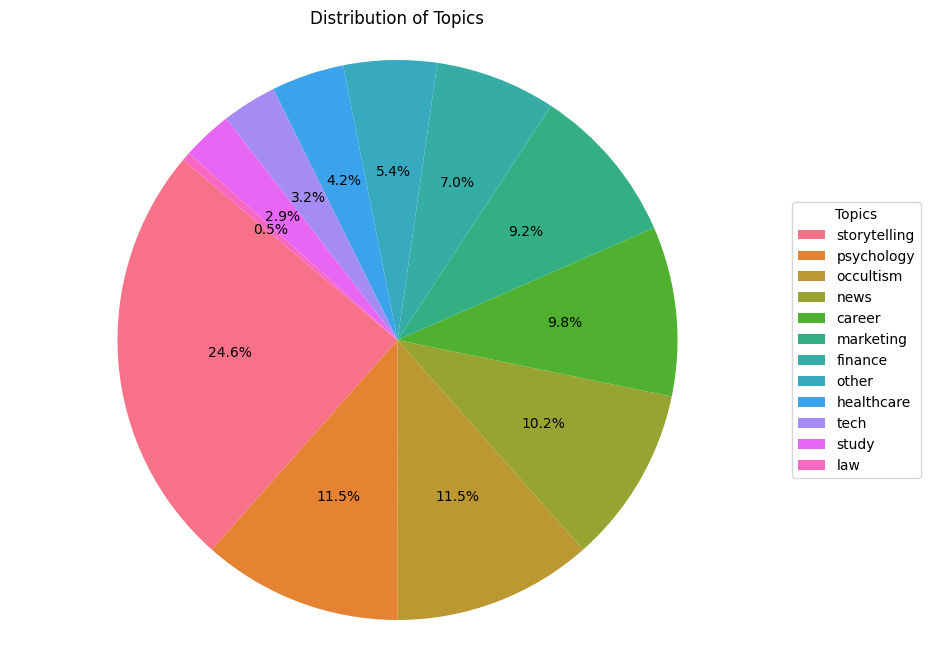

In [91]:
# Đếm số lượng từng loại topic
topic_counts = merged_df['topic'].value_counts(dropna=False)

# Tạo danh sách các màu sắc sử dụng bảng màu từ seaborn
colors = sns.color_palette('husl', len(topic_counts))

# Tạo biểu đồ hình tròn
labels = topic_counts.index.tolist()
sizes = topic_counts.values.tolist()

fig, ax = plt.subplots(figsize=(10, 8))

# Tạo biểu đồ hình tròn với màu sắc đã chọn
wedges, texts, autotexts = ax.pie(sizes, colors=colors, autopct='%1.1f%%', startangle=140)

# Thêm chú thích với một cột bên cạnh biểu đồ hình tròn
ax.legend(wedges, labels, title="Topics", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribution of Topics')
plt.axis('equal')  # Tỷ lệ bằng nhau đảm bảo hình tròn

# Hiển thị biểu đồ hình tròn
plt.show()

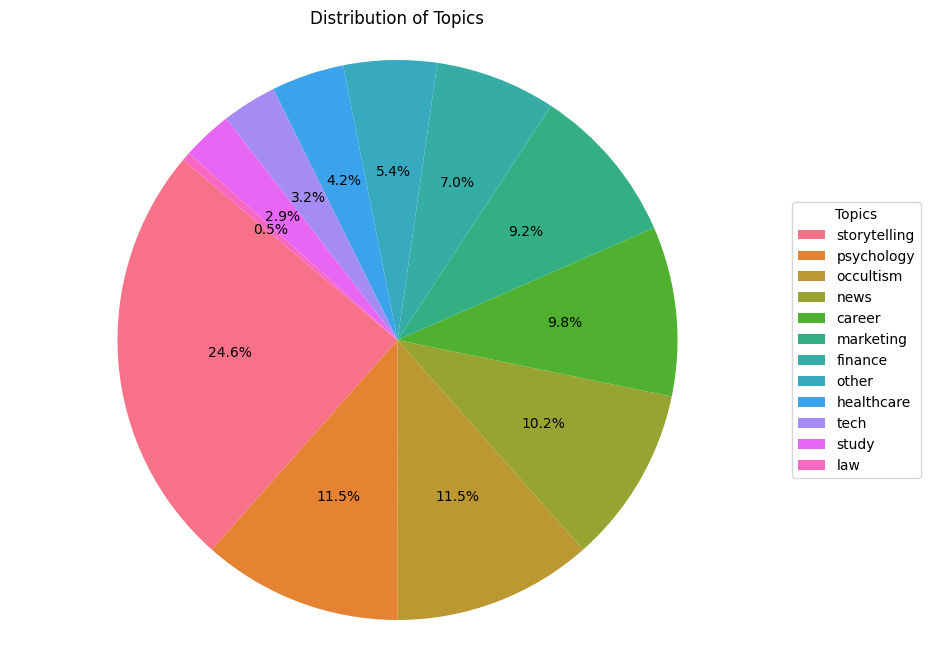

In [130]:
# Đếm số lượng từng loại topic
topic_counts = merged_df['topic'].value_counts(dropna=False)

# Tạo danh sách các màu sắc sử dụng bảng màu từ seaborn
colors = sns.color_palette('husl', len(topic_counts))

# Tạo biểu đồ hình tròn
labels = topic_counts.index.tolist()
sizes = topic_counts.values.tolist()

fig, ax = plt.subplots(figsize=(10, 8))

# Tạo biểu đồ hình tròn với màu sắc đã chọn
wedges, texts, autotexts = ax.pie(sizes, colors=colors, autopct='%1.1f%%', startangle=140)

# Thêm chú thích với một cột bên cạnh biểu đồ hình tròn
ax.legend(wedges, labels, title="Topics", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribution of Topics')
plt.axis('equal')  # Tỷ lệ bằng nhau đảm bảo hình tròn

# Lưu biểu đồ hình tròn vào file
output_filename = 'topic_distribution.png'
plt.savefig(output_filename)

# Hiển thị biểu đồ hình tròn
plt.show()

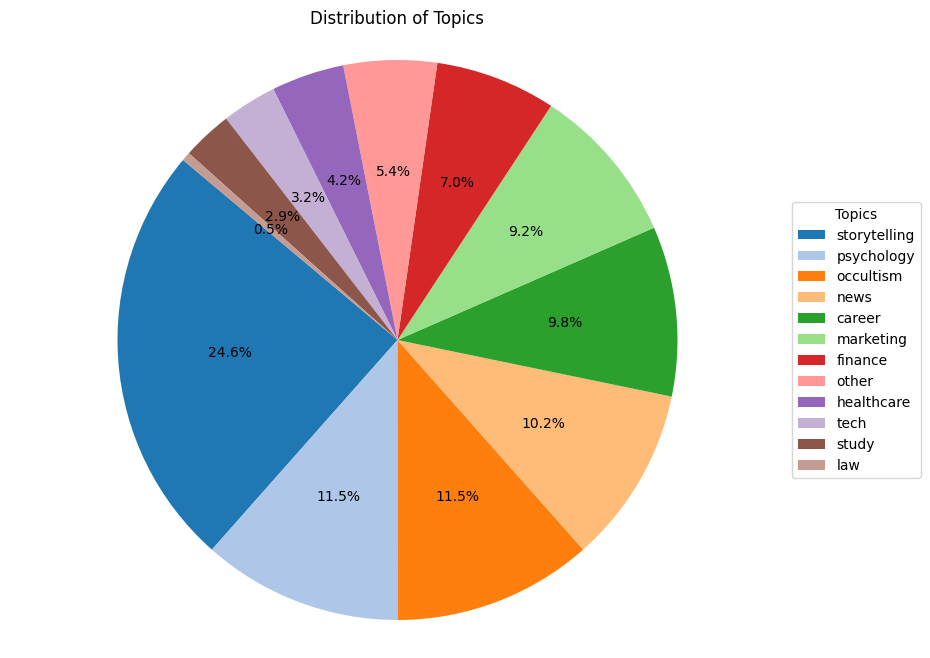

In [92]:
# Đếm số lượng từng loại topic
topic_counts = merged_df['topic'].value_counts(dropna=False)

# Tạo danh sách các màu sắc sử dụng bảng màu 'tab20'
colors = plt.get_cmap('tab20').colors

# Nếu số lượng topic nhiều hơn số màu trong bảng màu, ta sẽ lặp lại bảng màu để đủ màu
num_topics = len(topic_counts)
if num_topics > len(colors):
    colors = colors * (num_topics // len(colors) + 1)

# Tạo biểu đồ hình tròn
labels = topic_counts.index.tolist()
sizes = topic_counts.values.tolist()

fig, ax = plt.subplots(figsize=(10, 8))

# Tạo biểu đồ hình tròn với màu sắc đã chọn
wedges, texts, autotexts = ax.pie(sizes, colors=colors[:num_topics], autopct='%1.1f%%', startangle=140)

# Thêm chú thích với một cột bên cạnh biểu đồ hình tròn
ax.legend(wedges, labels, title="Topics", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribution of Topics')
plt.axis('equal')  # Tỷ lệ bằng nhau đảm bảo hình tròn

# Hiển thị biểu đồ hình tròn
plt.show()

In [67]:
news
'baothanhnien.official', 'thvl24news', 'kenh14specialvn', 'phanhoangmyvietjetair', 'tinmoinhat369', 'vtv4go', 'vtcnow', 'sieusaobongda09', 'dongthaptv', 
'thegeomedic', 'vtv24news', 'vtvthoitiet', 'weshare.asia', 'nhungvahung', 'cudau8', 'toiyeuvietnam1975', 'caocuongvu', '8saigon', 'nguyen2hoang2long', 'dicungdat', 
'langmaster_entertainment', 
finance
'tungbtkhoinghiep', 'sharktankvn', 'nqs.kinhte', 'ngocyakultinvesting', 'coin68tv', 'chuyenkinhdoanh_z', 'lamkhoinghiep', 'bahuy.henry', 'doctorhousing', 
'nguyenanhtuan.official', 'thanhhoctaichinh', 'hoangmanh8383', 'bbgchannel', 'chungkhoannessi', 'tkventuresvn', 'alexlevn', 'bocphottaichinh', 'sitcomtaichinh', 
'dungbanvang', 'mountain_nguyen', 'hatdecuoi75', 'thanh.nv', 'coachingmaster', 'digistockvn', 
Occultism
'behomethansohoc7', '_sunnytarot_', 'nhansohochieuminh', 'nhuantamlinh', 'thansohocdinhhuong369', 'chieu.tarotcorner', 'tamtinhmebim.mcv', 'astromazing.com', 
'phongthuythuctam', 'gwynethtarot777', 'congocphunxamtuongso', 'arian__111', 'earthlovers1111', 'tuan_linh912k', 'linhhoatam11', 'kenjinguyendinh', 'tinesomot', 
'vyviqng', 'ddttam', 'ami_wellness', 'nmc.act', 'thanhdaunguyen3', 'anratot102', 
Psychology
'ngocvanw', 'laihofficial', 'vothailamleo', '22_22_l', 'luonganhmyy', 'dangphuonglinh.com', 'tranquangtien164', 'giaolocamxuc.beeent', 'thalicvoice', 'macyennhu', 
'naiverosie', 'kieu06011993', 'ngatpronlp', 'baohancute205', 'codaolivestream', 'g84lebichngoc', 'ngocbinhtamly', 'taylortichcuc', 'cohathu.wegrow', 'a8hamhoc', 
'nguyenthu.official', 'hocvientommy', 'innerspacevn', 
study
'thesimpleha', 'tu_nguyen_it', 'chauchaukemtienganh', 'dr.hieuielts', 'khatienganh', 'binochemtienganh', 'hunghuynhdaotao', 'ieltsmentor.vietnam', 'gioiielts98', 
'civilis.duhochanquoc', 'datio89', 'msngan.panda', 'daothinhvuongofficial255', 'hochoimoingaymoi', 'dieuhoalanggo', 'nkhanhm2605', 'fpteduchill', 'homeenglishvn', 
'sangsang2x', 
career
'cohoichoai', 'thaihoang_huongnghiep', 'spiderumcareerguide', 'haitrieucareer', 'bamboocareers', 'topcv', 'thuuyendaylight', 'chuthienoi', 'huetran_taydanang', 
'find.forward', 'canmanhlinh', 'hanhchiase.xaykenh', 'duyennguyenkd', 'hieutheconsul', 'roseway68', 'otingting_networks', 'huydao', 'bukamidilam', 
'hqbt_laodonghanquoc', '_celine_nguyen', 'phamcu95', 'duongwiki', 'minhxinchao', 'vococenter_official', 'minh.lecong', 'maiivi8', 'landoanhr', 'tranle.phunu30cong', 
'truongphuongne', 'dotoearn', 'linhthaiofficial', 'xuan_affiliate', 'chuyennghe_', 'mitaminhtan', 'xangthuonghieu1', 'masteranhducpro', 'mcworld_daotaokynangmem', 
'bathucfood', 'phamquyet15121', 'anhtuanle2304', 'leo.cuong', 'thuyvuongday', 'manlethe', 'duyentuban', 'moedidauu', 'anhsacanh.marketik', 'rose.ng_', 
'the.innovators', 'quang.tm', 
healthcare
'duocsyduythuc90', 'fptlongchau', 'bacsicaohuuthinh', 'bacsi.hieu.official', 'bs.ngomonghung', 'duocsythaophan', 'unofficiallykyky', 'suckhoegenz', 'huuthinhbs', 
'dsnhidong', 'petjoy_chamsocthucung', 'behindthebeauty_zstudio', 'langhoa.workout', 'sebt.ccs', 'drchubbyderma', 'vantoi.calis', 'coimodi', 'vuongtuhoayogi', 
'dangbeo9', 'vietrilieu1006', 'kthahh', 'dr.ngomonghung', 'dhcvietnam.com.vn', 
storytelling
'onhadocsach', 'dangdocgiday', 'gasachh', 'hoangreaction', 'namkechuyenma', 'binh_storyteller', 'jaynguyen1101', 'dangthuhaf', 'syhuyvuituoi', 'chiemxi', 
'trieuvandeptrai', 'tamsuconggiao', 'phieunoinhieu', 'radiotamsu03', 'chualanhporn', 'snoop.pi', 'onlycofficial', 'quoctruong1988', 'mixximuse0305', 'mcanhphuong', 
'nguoilamphim69', 'tizidichlep.official', 'hoaquynh0000', 'chiyeuthoichuadu', 'datphinguyen', 'phamnguyenanhtu38h1', 'phammaihuong.pmh', 'ruto1009', 'camvothuat', 
'minhtinhday', 'ruto1009', 'phaminhiu', 'ngulong.official', 'vivodio', 'luongdinh1502', 'auhomaiuyn', 'zing.podcast', 'lepthelittlekid', 'thuyle2000', 'lenkangoo', 
'makebelieveshow', 'ngao_bao', 'minhminhhuongzai', 'duongduongpodcast', 'dc.podcast', 'chanchuoi.com', 'insidethebox.cchn', 'sunhuynn', 'vybarnouin',  'wingmanvn', 
'ntcong5', 'ccamthao', 'anthonyngofficial', 'nguyencanhluan', 'hongtotheheart', 'vtvgiaitriofficial', 'saigonteu', 'neko.land23', 'mixigaming', 'mcnguyenkhang', 
'realpewpew', 'tinhlong123', 'mcvtop.mcv', 'thayleodeptrai', 'phucmapvlog', 'truyd', 'hiubokho', 'giangkechuyen', 'khanhvyccf', 'the.tri.way', 'kich.nghe', 
'hitmaker.talkshow', 'phuongnamcomedian', 'bietduladuu', 'naniosaka', 'mioilami', 'binyetvlog', 'mcmisthy', 'dyxahmazl7at', 'hungdidu1907', 'topupodcast', 'ngantalk',
'quynhnhu.lifecoach', 'baothoalifecoach', 'vietsuccess',  'vietcetera_', 'thehoangwork', 'nguyenque.lifecoach', 'thongtruyentin', 'huynhduykhuongofficial', 
'radiotuanngoc', 'dtn.tuoidaythi', '5w1hpodcast', 'thayqueo', 'risingvietnam.podcast', 'nguyenquynhnaricantho', 'luongngo.lifecoach', 'tuquyenlifecoach', 
'nhile_anne92', 'ngominhtuan.official', 'anhduc.masterlife', 'luatsux', 'chinhchualon', 'lifecoachtuean', 'pphicoach', 'chiemthanhlich', 'giangoivlog', 
'hien.thichhat', 'ph.khg', 'kobe.media79', 'nawngs.official', 'htx.tienbo', 'tieuthu.chanrau', 'remind.ne', 'son.me.hoc', 
marketing
'marketingcungadam', 'truesmart.vn', 'gearvn.store', 'marketingthucchien', 'chau_muoi', 'hianle21.marketing', 'hoangngoctu68', 'henantrua.mcv', 'lydapotato', 
'tanab.ne', 'madisonmediagroup', 'vuilenreview', 'maggiemaggievn', 'truyenthongkhangofficial', '_thangtaipei_', 'markusnguyen37', 'khanh.sartorial', 'ducreaction', 
'ggstravel.khamphanhatban', 'vn.joboko', 'fisc.vn', 'dyhayho', 'withvung', 'baophuonglatui', 'meowamnhac', 'chuyen_n', 'wesleyn313', 'dongocthien_hip', 
'theinfluencer.vn', 'hanquangdu', '28perfume1', 'linh.gb', 'paulduongcanada', 'catherineyenpham', 'chubeo.dayyy', 'hongthuy68.78', 'mtsmart.vn', 'haiichieu', 
'chubandaugio', 'kienkhongngu_official', 'virussvn', 'quankhonggo', 'apinvy', 'meizkhumm', 'saigonspringroll', 'dinovux', 'thangmucbang', 'nonkhanran', 'gaufamilyy', 
'sabrina.uyenluu', 'fqa.mp5', 'yoursupp.vn', 
tech
'vatvostudio', 'sonapple88', 'thedev_dad', 'trumdidong.vn', 'soncalltech', 'cobaedit7', 'cellphones.updatedoday', 'phuongcongnghe', 'cafetek', 'hantuyentech', 
'iiiiphone', 'taotechvn', 'vinhvatvofake', 'longkhoahoc', 'bimatgoogle', 'adminkhaofficial', 'pcm.studio', 'chill_with_dan', 'duyluandethuong', 'tunggg.pham', 
'duyyy.real.channel', 'nhitho2000', 'anphat.official', 'lantechvn', 'tan.sualaptop', 'danchoihetao', 'neyakowo', 'hungkhucc', 'dong.congnghe', 'vietargue', 
'kienthanhle90', 'alongoc.nghe', 
law
'trungluatsu', 'phamcanhlinh', 'haluatsu', 'luatsubinh', 
       
       'ha_hips',

       
       'emanhbobeo02',
       
       'genz.justdoit',
       '1900.6996_',
       

       'linhmayy2003', 'mai_luong_tsh',
       'bobsgb', 'metv.tiktok', 
       'love_and_maturity', 

       'linhmayy03', 
       
       'thangbancaytinikun', 
       'duynghiem.dgi', 'brands_untold', 
       'thiendi180119',
       'taiphen', 
       'vttm_official',
       'trungthucedu', 'quynhcuaneee', 'trananhtu249', 
       
       'tntamnguyen92', 'nguyenphuonghuyen_tsh', 'quyquy_2', 

IndentationError: unexpected indent (1627233451.py, line 28)

In [28]:
df.channel.unique()

array(['nguyenquynhnaricantho', 'baothanhnien.official',
       'behomethansohoc7', 'ngocvanw', 'thvl24news', 'laihofficial',
       'dr.hieuielts', 'bahuy.henry', 'unofficiallykyky', 'cohoichoai',
       'datio89', 'hoangngoctu68', 'truesmart.vn', 'henantrua.mcv',
       'lydapotato', 'nhile_anne92', 'ngominhtuan.official',
       'anhduc.masterlife', 'mcnguyenkhang', 'duocsyduythuc90',
       'vothailamleo', 'luatsux', '22_22_l', 'thuuyendaylight',
       'luonganhmyy', 'tanab.ne', 'khatienganh', 'tinhlong123',
       'onhadocsach', 'phammaihuong.pmh', 'dangphuonglinh.com',
       'tranquangtien164', 'giaolocamxuc.beeent', 'msngan.panda',
       'phamcanhlinh', 'vtvgiaitriofficial', 'binochemtienganh',
       'vatvostudio', 'thangbancaytinikun', 'sonapple88', 'thalicvoice',
       'duynghiem.dgi', 'brands_untold', 'macyennhu', 'realpewpew',
       'phamnguyenanhtu38h1', 'mcvtop.mcv', 'kenh14specialvn',
       'vietsuccess', '_sunnytarot_', 'daothinhvuongofficial255',
       'dangdocg

In [27]:
len(df)

1254385

In [32]:
df[df.video.str.contains('730979009993428507400000')]

,id,shard,split,channel,video
0,70925,1,valid,nguyenquynhnaricantho,730979009993428507400000-84-87
1070,70886,1,valid,nguyenquynhnaricantho,730979009993428507400000-2-5
4930,70929,1,valid,nguyenquynhnaricantho,730979009993428507400000-92-95
8407,70918,2,valid,nguyenquynhnaricantho,730979009993428507400000-70-73
9248,70900,2,valid,nguyenquynhnaricantho,730979009993428507400000-34-37
...,...,...,...,...,...
121852,70933,20,valid,nguyenquynhnaricantho,730979009993428507400000-100-103
122825,70953,20,valid,nguyenquynhnaricantho,730979009993428507400000-144-147
125733,70888,21,valid,nguyenquynhnaricantho,730979009993428507400000-6-9
126605,70909,21,valid,nguyenquynhnaricantho,730979009993428507400000-52-55


In [38]:
df['channel'].value_counts().head(15)

channel
behomethansohoc7          32370
thvl24news                24243
nguyenquynhnaricantho     23990
ngocvanw                  23617
baothanhnien.official     23322
tuan_linh912k             21971
genz.justdoit             21242
nguyenanhtuan.official    20868
tamtinhmebim.mcv          20598
lifecoachtuean            19888
vtvthoitiet               19477
laihofficial              17782
luonganhmyy               15496
mcvtop.mcv                15488
vothailamleo              14116
Name: count, dtype: int64